# 15 - Dashboard E-Commerce (KPI)

Dalam notebook ini saya akan menghitung KPI penjualan dari data E-Commerce nyata, lalu menyusun beberapa grafik dalam 1 canvas menyerupai Dashboard

 **Tujuan Pembuatan dan Pembelajaran**

 -> Menghitung KPI Penjualan : Total Revenue, Jumlah Order Unik, AOV
 -> Menemukan Top Negara dan Top Product
 -> Menyusun beberapa Grafik dalam 1 Figur sebagai Dashboard
 -> Mneyajikan tabel KPI secara Ringkas



## Tentang Dataset

Berisi sekitar 541 ribu baris transaksi peritel Online Inggris ( 2010 -2011 )
 - Tiap Baris mewakili 1 item dalam sebuah faktur
 - Sumber Kaggle : [Kaggle — carrie1/ecommerce-data](https://www.kaggle.com/datasets/carrie1/ecommerce-data)
 - dimuat dengan encoding="ISO-8859-1"

Kolom Kunci :  `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`,`CustomerID`, `Country`

tambahkan kolom baru `Revenue` = Quantity * Unitprice


| Kolom | Arti |
|-------|------|
| `InvoiceNo` | Nomor faktur (diawali 'C' = pembatalan) |
| `StockCode` | Kode produk |
| `Description` | Nama produk |
| `Quantity` | Jumlah unit (bisa negatif = retur) |
| `InvoiceDate` | Tanggal & waktu transaksi |
| `UnitPrice` | Harga satuan (GBP) |
| `CustomerID` | ID pelanggan |
| `Country` | Negara pelanggan |

## 1.Import Library

  - Pandas
  - Numpy
  - Matplotlib
  - Seaborn

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2.Import Dataset

In [23]:
!pip install -q kaggle
!kaggle datasets download -d carrie1/ecommerce-data
!unzip -qq ecommerce-data.zip


Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
ecommerce-data.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


#3.Explorasi sederhana dataset

In [24]:
data = pd.read_csv('data.csv', encoding="ISO-8859-1")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [26]:
data.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [27]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


Interpretasi :    
- InvoiceDate masih dalam bentuk teks, perlu diubah menjadi bentuk datetime
- terdapat banyak missing value, di kolom CustomerID dan Description
- terdapat nilai minus di kolom Quantity dan UnitPrice
- Dataset terdiri dari 541909 baris dan 8 kolom

#4.Cleaning dataset

## 1.Ubah data obejct pada InvoceDate menjadi format waktu


In [28]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

## 2.Buang / drop Transaksi dengan Quantity dan unit Price dibawah 0 / <= 0

In [29]:
sebelum_dihapus = len(data)

#pertahankan yang lebih besar dari 0
data = data[(data["Quantity"]>0)&(data["UnitPrice"]>0)]

setelah_dihapus = len(data)

print(f"Jumlah baris sebelum dihapus : {sebelum_dihapus}")
print(f"Jumlah baris setelah dihapus : {setelah_dihapus}")
print(f"Jumlah baris yang dihapus : {sebelum_dihapus-setelah_dihapus}")

Jumlah baris sebelum dihapus : 541909
Jumlah baris setelah dihapus : 530104
Jumlah baris yang dihapus : 11805


## 3.Tambahkan Kolom baru (Revenue) hasil perkalian dari Quantity dengan Unit Price

In [30]:
data["revenue"] = data["Quantity"]*data["UnitPrice"]
data.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


Interpretasi :     

- Kita sudah membuang 11805 baris yang tidak sesuai dengan kriteria
- Data tanggal sudah diubah datatypenya menjadi datetime
- Data baru (revenue) sudah dibuat untuk mempermudah mengaggregasikan hasil selanjutnya

Data sudah di bersihkan,

  -  Karna KPI adalah agregasi, jadi harus memakai seluruh baris yang valid ( bukan sample ) agar total revenue dan jumlah order akurat
  - Untuk grafik tertentu memakai hasil agregasi yang sudah ringkas

#5.Menghitung KPI Utama

definisi :     
  - Total revenue = jumlah seluruh `revenue`
  - Jumlah order unik = banyaknya `InvoiceNo`  
  - `AOV` average order value = Total Revenue / Jumlah Order Unik
  - Jumlah pelanggan unik & Jumlah produk unik sebagai pelengkap

In [31]:
total_revenue = data["revenue"].sum()

jumlah_order = data["InvoiceNo"].nunique()

aov = total_revenue/jumlah_order

jumlah_pelanggan = data["CustomerID"].nunique()

jumlah_produk = data["StockCode"].nunique()

jumlah_negara = data["Country"].nunique()

In [42]:
def tabel_kpi(kpi: dict, judul: str = "Ringkasan KPI"):
    """Sajikan dict KPI sebagai tabel yang tertata."""
    df = pd.DataFrame({
        "KPI": list(kpi.keys()),
        "Nilai": list(kpi.values())
    })

    def _fmt(v):
        if isinstance(v, (int, float)):
            return f"{v:,.2f}" if isinstance(v, float) else f"{v:,}"
        return v

    df["Nilai"] = df["Nilai"].map(_fmt)

    return (
        df.style
        .hide(axis="index")
        .set_caption(judul)
        .set_properties(**{
            "text-align": "left",
            "font-size": "13px"
        })
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "15px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "6px 0")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#2C3E50"),
                    ("color", "white"),
                    ("text-align", "left"),
                    ("padding", "6px 12px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "6px 12px")
                ]
            },
        ])
    )

In [43]:
KPI = {
    "total_revenue": round(total_revenue,0),
    "jumlah_order": jumlah_order,
    "aov": round(aov,2),
    "jumlah_pelanggan": jumlah_pelanggan,
    "jumlah_produk": jumlah_produk,
    "jumlah_negara": jumlah_negara
}

tabel_kpi(KPI)

KPI,Nilai
total_revenue,"10,666,685.00"
jumlah_order,"19,960.00"
aov,534.40
jumlah_pelanggan,"4,338.00"
jumlah_produk,"3,922.00"
jumlah_negara,38.00


Interpretasi :     
  - Tabel ini adalah ringkasan eksekutif
  - Total Revenue beberapa juta GBP dari puluhan ribu order
  - AOV menunjukkan rata rata belanja / faktur pembelian ( Metrik penting untuk upselling )
  - Bisnis ini melayani pasar yang multinational

# 6.Komponen Dashboard Utama

siapkan data agregasi untuk setiap grafik/panel dashboard ( Top Country , Top Product ,  Trend Bulanan )

In [72]:
#10 top country
top_10_country = data.groupby("Country")["revenue"].sum().sort_values(ascending=False).head(10)
top_10_country.head()

,revenue
Country,
United Kingdom,9025222.084
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110


In [46]:
#revenue bulanab
monthly_revenue = data.groupby(data["InvoiceDate"].dt.to_period("M"))["revenue"].sum()
monthly_revenue.head()

,revenue
InvoiceDate,
2010-12,823746.140
2011-01,691364.560
2011-02,523631.890
2011-03,717639.360
2011-04,537808.621


In [47]:
#top_country_exclude_UK

top_non_uk = (data[data["Country"]!="United Kingdom"].groupby("Country")["revenue"].sum().sort_values(ascending=False).head(10))
top_non_uk

,revenue
Country,
Netherlands,285446.34
EIRE,283453.96
Germany,228867.14
France,209715.11
Australia,138521.31
Spain,61577.11
Switzerland,57089.90
Belgium,41196.34
Sweden,38378.33


Interpretasi:
  -  UK sangat mendominasi pasar, maka dari itu siapkan top country selain UK


In [49]:
#Nilai revenue per order
order_value = data.groupby("InvoiceNo")["revenue"].sum()
order_value_small = order_value[order_value < order_value.quantile(0.95)]

# 7.Menyusun Dashboard(Subplot)


menggabungjan 4 panel dalam figure 2 x 2 dengan `subplot`
- Tren Bulanan
- Top Country non UK
- Top Produk
- Distribusi nilai order

/tmp/ipykernel_804/4060577809.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_non_uk.values, y=top_non_uk.index,
/tmp/ipykernel_804/4060577809.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_country.values, y=top_10_country.index,
/tmp/ipykernel_804/4060577809.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(order_value_small, bins=30, ax=axes[1,1],


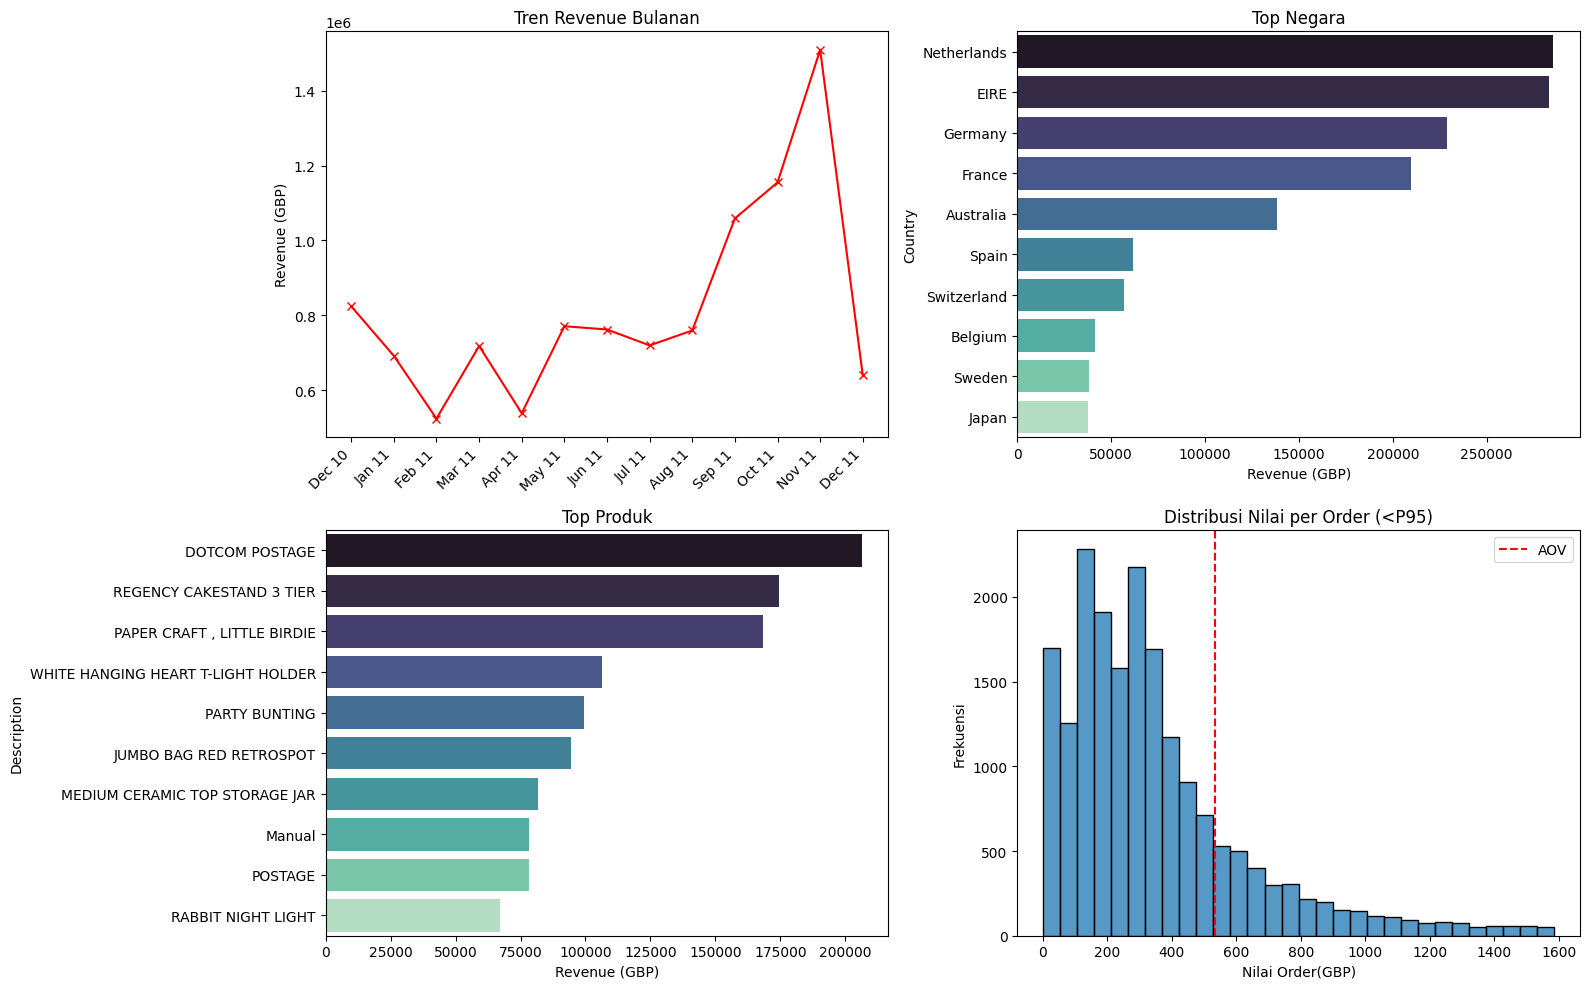

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#Panel 1: Trend Bulanan
axes[0,0].plot(range(len(monthly_revenue)), monthly_revenue.values, marker="x", color="red")
axes[0,0].set_xticks(range(len(monthly_revenue)))
axes[0,0].set_xticklabels([d.strftime("%b %y") for d in monthly_revenue.index], rotation=45, ha="right")
axes[0,0].set_title("Tren Revenue Bulanan")
axes[0,0].set_ylabel("Revenue (GBP)")

#Panel 2: Top Negara non UK
sns.barplot(x=top_non_uk.values, y=top_non_uk.index,
            palette="mako",
            ax=axes[0,1])
axes[0,1].set_title("Top Negara")
axes[0,1].set_xlabel("Revenue (GBP)")


#Panel 3: Top Produk
sns.barplot(x=top_10_country.values, y=top_10_country.index,
            palette="mako",
            ax=axes[1,0])
axes[1,0].set_title("Top Produk")
axes[1,0].set_xlabel("Revenue (GBP)")

#Panel 4: Distribusi nilai order
sns.histplot(order_value_small, bins=30, ax=axes[1,1],
             palette="set2")
axes[1,1].axvline(aov, color="red", linestyle="--")
axes[1,1].set_title("Distribusi Nilai per Order (<P95)")
axes[1,1].set_xlabel("Nilai Order(GBP)")
axes[1,1].set_ylabel("Frekuensi")
axes[1,1].legend(["AOV"])

plt.tight_layout()
plt.show()

Interpretasi:
  - Trend bulanan naik menuju akhir 2011 ( Nataru ) ; Desember terpotong sehingga tren turun
  - Pasar Mancanegara di pimpin oleh belanda, Irlandia, Jerman dan Perancis
  - Top Produk di dominasi pernak pernik dekorasi / gift bernilai jua tinggi
  -  Distribusi nilai order menceng: didominasi dengan nilai order kecil  dan sedikit dengan order besar, redline menandai posisi AOV

# 8.Top Negara termasuk UK,

sertakan negara UK sebagai homebase ecommerce


##Top 10 Country termasuk UK

/tmp/ipykernel_804/797199147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_country.values, y=top_10_country.index,


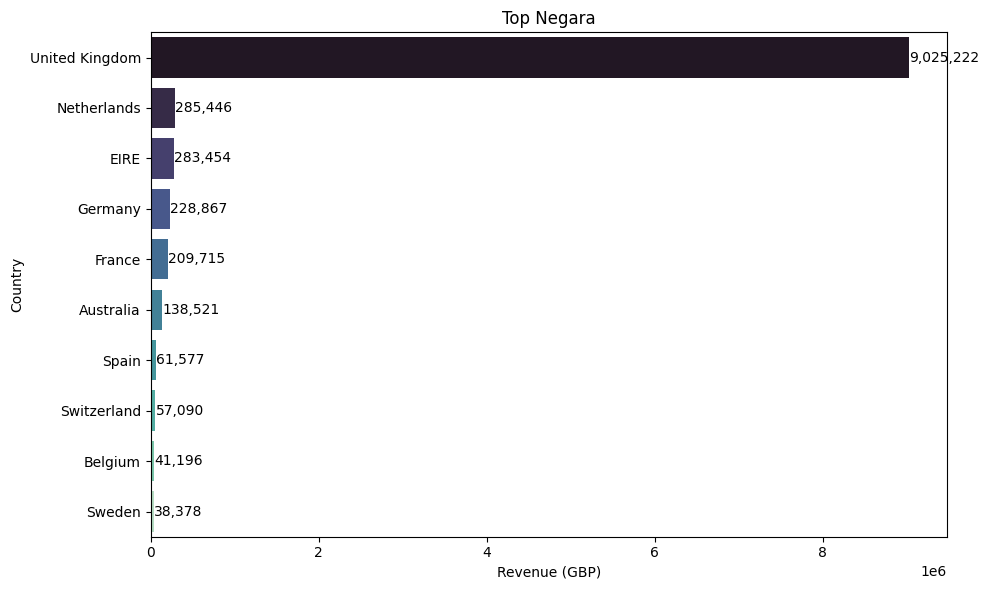

In [77]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_country.values, y=top_10_country.index,
            palette="mako")
#plt.xscale("log")
plt.title("Top Negara")
plt.xlabel("Revenue (GBP)")
#annotate
for i, v in enumerate(top_10_country.values):
    plt.text(v, i, f"{v:,.0f}", ha="left", va="center")
plt.tight_layout()
plt.show()

**Interpretasi:**  
  - **United Kingdom** jauh di atas negara lain — menegaskan bisnis ini sangat bergantung pada **pasar domestik**. Diversifikasi pasar bisa menjadi rekomendasi strategis.

##Grafik Perbanding UK vs Non UK

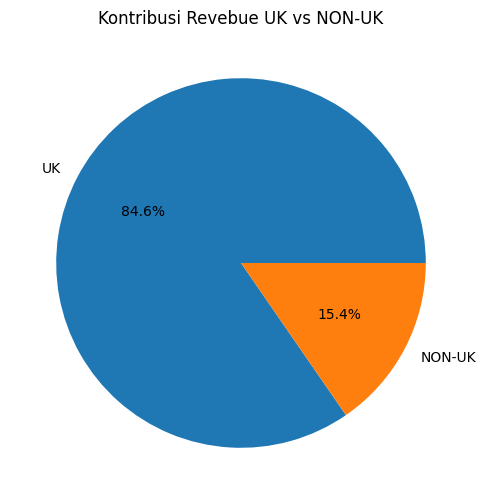

In [80]:
rev_uk = data[data["Country"]=="United Kingdom"]["revenue"].sum()
rev_non_uk = data[data["Country"]!="United Kingdom"]["revenue"].sum()

plt.figure(figsize=(10, 6))
plt.pie([rev_uk, rev_non_uk], labels=["UK", "NON-UK"],
        autopct="%1.1f%%")

plt.title("Kontribusi Revebue UK vs NON-UK")
plt.show()

Interpretasi:
  - Pie chart memperkuat temuan: **mayoritas besar revenue** berasal dari UK.
Ketergantungan tinggi pada satu pasar adalah **risiko bisnis** yang perlu diperhatikan manajemen.

# Kesimpulan dan Insight
  - KPI : Total Revenue , jumlah Order , AOV, memberi gambaran kesehatan bisnis sekejap
  -  UK Mendominasi Revenue -  Peluang sekaligus resiko ( Ketergantungan Market Domestik )
  - Penjualan musiman, Memuncak menjelang Natal dan Tahun baru
  -  Sebagian besar order bernilai rendah; sedikit order besar mengankat total - fokus upselling untuk menaikan AOV
  - Menyusun Grafik dalam 1 Dashboard memudahkan penyampaian informasi kepada stakeholder terkait untuk mempercepat pengambilan keputusan

  Dashboard ini bisa kembangkan lagi sesuai kebutuhan bisnis dan data yang tersedia




### ⚠️ Jebakan Data

- **United Kingdom mendominasi** revenue. Metrik "rata-rata global" jadi **menyesatkan** —
  hampir semuanya mencerminkan UK. Pisahkan UK vs non-UK agar pasar internasional terlihat jujur.
- **AOV** = total revenue ÷ jumlah order, sehingga **sangat sensitif terhadap order raksasa**
  (grosir). Lihat juga **median** nilai order, bukan hanya rata-rata.